In [ ]:
"""
MAE 6760 Model Based Estimation
Cornell University
M Campbell

Homework #3
Problem #1: Kalman Filter
    five mass–spring–damper system
    uses the following Python functions:
        plot_openloop.py
        plot_estimator.py
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import cont2discrete
from scipy.linalg import solve_discrete_are

from plot_openloop import plot_openloop
from plot_estimator import plot_estimator

In [ ]:
# ------------------------------------------------------------
# Define continuous-time system
# ------------------------------------------------------------
k1=k2=k3=k4=k5=1
c1=c2=c3=c4=c5=0.01
m1=m2=m3=m4=m5=1

nx = 10
Fc = np.zeros((nx,nx))

# stiffness
Fc[np.ix_([1,3,5,7,9],[0,2,4,6,8])] = np.array([
    [-(k1+k2)/m1,  (k2)/m1,      0,        0,      0],
    [ (k2)/m2, -(k2+k3)/m2, (k3)/m2,      0,      0],
    [ 0, (k3)/m3, -(k3+k4)/m3, (k4)/m3,   0],
    [ 0, 0, (k4)/m4, -(k4+k5)/m4, (k5)/m4],
    [ 0, 0, 0, (k5)/m5, -(k5)/m5]
])

# damping
Fc[np.ix_([1,3,5,7,9],[1,3,5,7,9])] = np.array([
    [-(c1+c2)/m1, (c2)/m1, 0, 0, 0],
    [ (c2)/m2, -(c2+c3)/m2, (c3)/m2, 0, 0],
    [0,(c3)/m3, -(c3+c4)/m3,(c4)/m3,0],
    [0,0,(c4)/m4, -(c4+c5)/m4,(c5)/m4],
    [0,0,0,(c5)/m5, -(c5)/m5]
])

# kinematics
Fc[np.ix_([0,2,4,6,8],[1,3,5,7,9])] = np.eye(5)

# disturbance on 5th mass
Gc = np.zeros((nx,1))
Gc[9,0] = 1/m5

# position msmts on 1st and 5th masses
i1 = 0
Hq1 = np.zeros((1,nx))
Hq1[0,i1] = 1        # q1
i5 = 8
Hq5 = np.zeros((1,nx))
Hq5[0,i5] = 1        # q5
Hc = np.vstack((Hq1, Hq5))

# discrete time model
dt = 0.05
F, G, _, _, _ = cont2discrete((Fc, Gc, Hc, 0), dt)

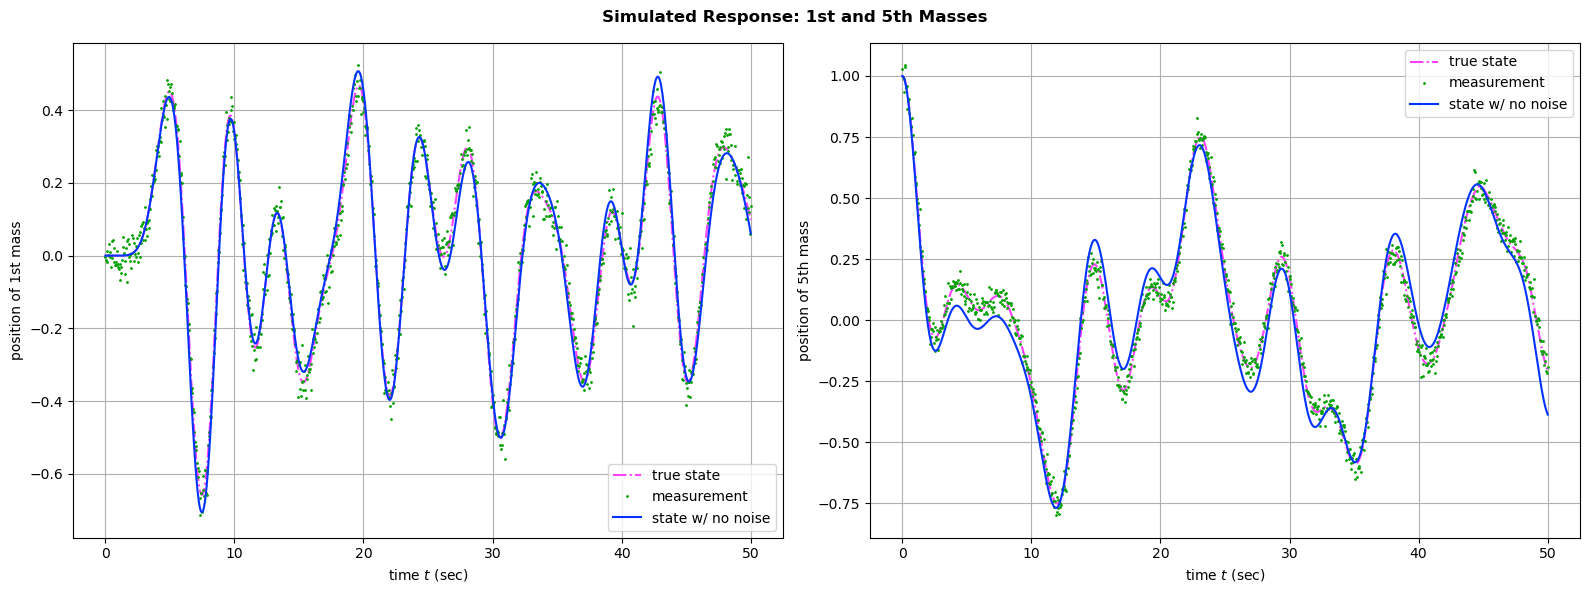

In [3]:
# ------------------------------------------------------------
# Simulate system
# ------------------------------------------------------------
t = np.arange(0,50+dt,dt)
nk = len(t)

x0 = np.zeros(nx)
x0[8] = 1

np.random.seed(101)
Qsim = 0.01
w = np.sqrt(Qsim)*np.random.randn(1,nk)

x_true = np.zeros((nx,nk))
x_no_w = np.zeros((nx,nk))
x_true[:,0] = x0
x_no_w[:,0] = x0

for k in range(nk-1):
    x_no_w[:,k+1] = F @ x_no_w[:,k]
    x_true[:,k+1] = F @ x_true[:,k] + G @ w[:,k]

# measurements
Rq1 = 0.001
Rq5 = 0.001
z_q1 = (Hq1 @ x_true + np.sqrt(Rq1)*np.random.randn(1,nk)).ravel() # scalar msmt
z_q5 = (Hq5 @ x_true  + np.sqrt(Rq5)*np.random.randn(1,nk)).ravel() # scalar msmt


# ------------------------------------------------------------
# Open-loop plots
# ------------------------------------------------------------
fig, axs = plt.subplots(1,2,figsize=(16,6))

plot_openloop(t, x_true[i1,:], z=z_q1,
              x_no_w=x_no_w[i1,:], ax=axs[0])
axs[0].set_ylabel("position of 1st mass")

plot_openloop(t, x_true[i5,:], z=z_q5,
              x_no_w=x_no_w[i5,:], ax=axs[1])
axs[1].set_ylabel("position of 5th mass")

fig.suptitle("Simulated Response: 1st and 5th Masses",
             fontweight='bold')

plt.tight_layout()

In [ ]:
# ------------------------------------------------------------
# (a) KF using z_q1
# ------------------------------------------------------------
# uses: Hq1, Rq1, z_q1
#

## YOUR CODE HERE

#initialize
xhatk_k = x0
Pk_k = 1 * np.eye(nx)

#preallocate
xhatu = np.zeros((nx,nk))
Pu = np.zeros((nx,nx,nk))
GQGT = Qsim*(G@G.T)
I =np.identity(nx)


for i in range(nk):
    xhatu[:,i] = xhatk_k
    Pu[:,:,i] = Pk_k

    #predict
    xhatk1_k = F@xhatk_k
    Pk1_k = F@Pk_k@F.T + GQGT

    #Kalman Gain
    Kk1 = Pk1_k@Hq1.T @ np.linalg.inv(Hq1@Pk1_k@Hq1.T + Rq1)

    #update

    xhatk1_k1 = xhatk1_k + Kk1@(z_q1[i] - Hq1@xhatk1_k)
    Pk1_k1 = (I - Kk1@Hq1)@Pk1_k@(I - Kk1@Hq1).T + Rq1*Kk1@Kk1.T

    # relabel to iterate
    Pk_k = Pk1_k1
    xhatk_k = xhatk1_k1

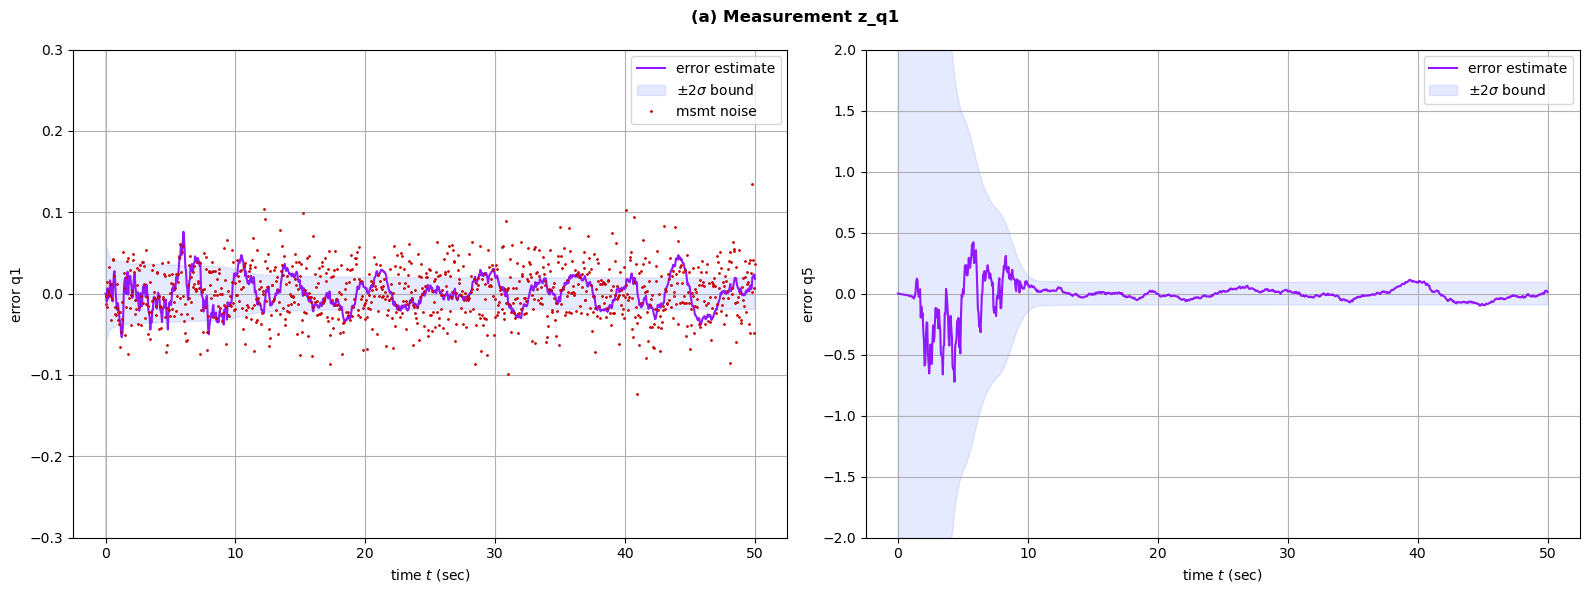

In [36]:
fig, axs = plt.subplots(1,2,figsize=(16,6))

plot_estimator(t, xhatu[i1,:], Pu[i1,i1,:],
               x_true[i1,:], plot_type='error',
               z=z_q1, ax=axs[0])
axs[0].set_ylim([-0.3,0.3])
axs[0].set_ylabel("error q1")

plot_estimator(t, xhatu[i5,:], Pu[i5,i5,:],
               x_true[i5,:], plot_type='error',
               ax=axs[1])
axs[1].set_ylim([-2,2])
axs[1].set_ylabel("error q5")

fig.suptitle("(a) Measurement z_q1", fontweight='bold')
plt.tight_layout()



In [37]:
# ------------------------------------------------------------
# (a) KF using z_q5
# ------------------------------------------------------------
# uses: Hq5, Rq5, z_q5
#

## YOUR CODE HERE

#initialize
xhatk_k = x0
Pk_k = 1 * np.eye(nx)

#preallocate
xhatu = np.zeros((nx,nk))
Pu = np.zeros((nx,nx,nk))
GQGT = Qsim*(G@G.T)
I =np.identity(nx)


for i in range(nk):
    xhatu[:,i] = xhatk_k
    Pu[:,:,i] = Pk_k

    #predict
    xhatk1_k = F@xhatk_k
    Pk1_k = F@Pk_k@F.T + GQGT

    #Kalman Gain
    Kk1 = Pk1_k@Hq5.T @ np.linalg.inv(Hq5@Pk1_k@Hq5.T + Rq5)

    #update

    xhatk1_k1 = xhatk1_k + Kk1@(z_q5[i] - Hq5@xhatk1_k)
    Pk1_k1 = (I - Kk1@Hq5)@Pk1_k@(I - Kk1@Hq5).T + Rq5*Kk1@Kk1.T

    # relabel to iterate
    Pk_k = Pk1_k1
    xhatk_k = xhatk1_k1

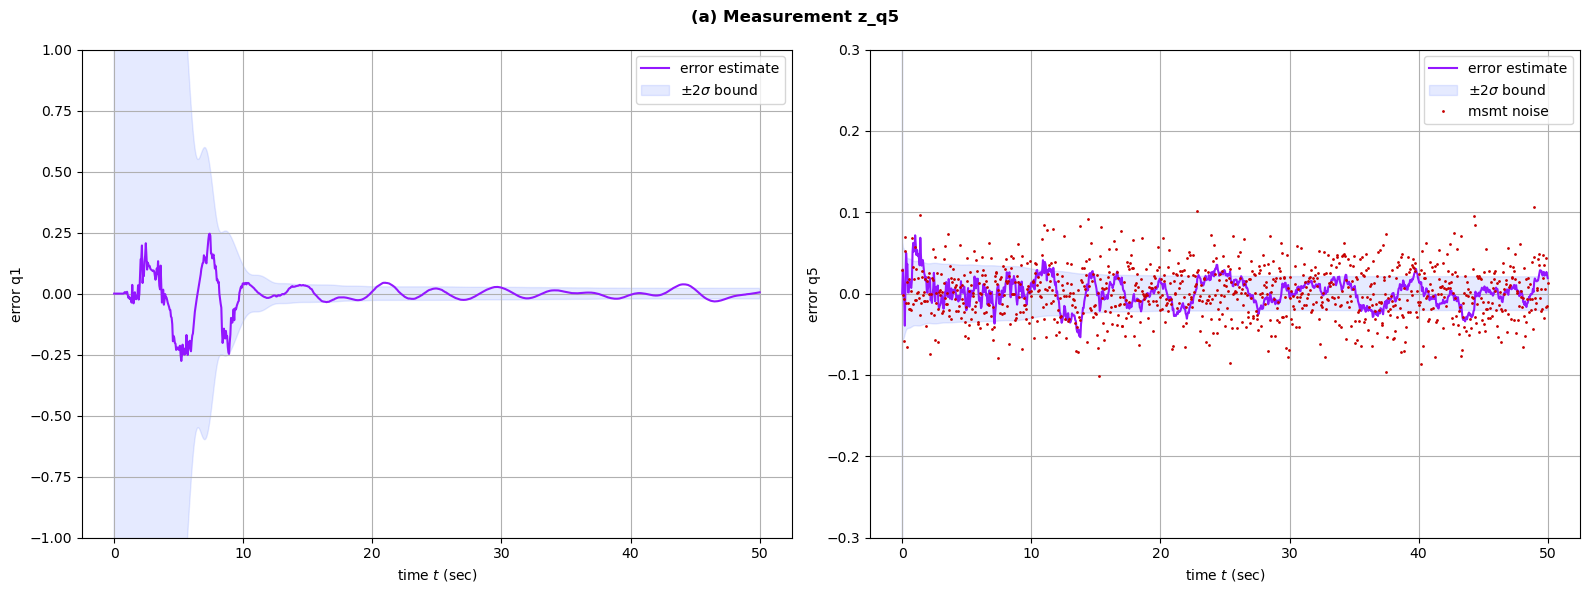

In [38]:


fig, axs = plt.subplots(1,2,figsize=(16,6))

plot_estimator(t, xhatu[i1,:], Pu[i1,i1,:],
               x_true[i1,:], plot_type='error',
               ax=axs[0])
axs[0].set_ylim([-1,1])
axs[0].set_ylabel("error q1")

plot_estimator(t, xhatu[i5,:], Pu[i5,i5,:],
               x_true[i5,:], plot_type='error',
               z=z_q5, ax=axs[1])
axs[1].set_ylim([-0.3,0.3])
axs[1].set_ylabel("error q5")

fig.suptitle("(a) Measurement z_q5", fontweight='bold')
plt.tight_layout()


In [30]:
# ------------------------------------------------------------
# (b) Predicted vs Updated covariance
# ------------------------------------------------------------
# uses: Hq5, Rq5, z_q5
#       solve_discrete_are
#

## YOUR CODE HERE

plt.figure(figsize=(8,6))
plt.semilogy(t, Pp[i5,i5,:], 'b:', label="predicted")
plt.semilogy(t, Pu[i5,i5,:], 'r-', label="updated")
plt.ylim([1E-4,1E-3])
plt.grid(True)
plt.xlabel("time (sec)")
plt.ylabel("estimate")
plt.legend()
plt.title("(b) Predicted vs Updated")

# ------------------------------------------------------------
# (b) Steady State error covariance
# ------------------------------------------------------------

## YOUR CODE HERE

print("Simulated measurement covariance at the final time is:")
print(Pz_sim)
print("Steady-state measurement covariance is:")
print(Hq5 @ Pss @ Hq5.T)




NameError: name 'Pp' is not defined

<Figure size 800x600 with 0 Axes>

In [ ]:
# ------------------------------------------------------------
# (d) Constant gain KF
# ------------------------------------------------------------
# uses: Hq5, Rq5, z_q5
#       solve_discrete_are
#


fig, axs = plt.subplots(1,2,figsize=(16,6))

plot_estimator(t, xhatu[i1,:], Pu[i1,i1,:],
               x_true[i1,:], plot_type='error',
               ax=axs[0])
axs[0].set_ylim([-0.1,0.1])
axs[0].set_ylabel("error q1")

plot_estimator(t, xhatu[i5,:], Pu[i5,i5,:],
               x_true[i5,:], plot_type='error',
               z=z_q5, ax=axs[1])
axs[1].set_ylim([-0.2,0.2])
axs[1].set_ylabel("error q5")

fig.suptitle("(d) Constant KF Gain with msmt ", fontweight='bold')
plt.tight_layout()

plt.show()